In [1]:
#| hide
from nbdev import *

# HECSS
> High Efficiency Configuration Space Sampler

HECSS is a Monte-Carlo, configuration space sampler using sample weighting algorithm for probability distribution sampling. It provides an alternative way to create representations of systems at thermal equilibrium without running a very expensive molecular dynamics simulation. The theoretical foundation of the code are presented in the section [Background](background.html) in the [Documentation](https://jochym.github.io/hecss/). More detailed examples are included in the [LAMMPS](lammps_tutorial.html) and [VASP](vasp_tutorial.html) tutorials.

You can try HECSS on binder: [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gl/jochym%2Fhecss/devel?labpath=nbs/index.ipynb)

[![PVersion Badge](https://img.shields.io/pypi/v/hecss.svg)](https://pypi.org/project/hecss/)
[![PDownloads Badge](https://img.shields.io/pypi/dm/hecss.svg)](https://pypi.org/project/hecss/)
[![CVersion Badge](https://anaconda.org/conda-forge/hecss/badges/version.svg)](https://anaconda.org/conda-forge/hecss)
[![Downloads Badge](https://anaconda.org/conda-forge/hecss/badges/downloads.svg)](https://anaconda.org/conda-forge/hecss)
[![License Badge](https://anaconda.org/jochym/hecss/badges/license.svg)](https://anaconda.org/jochym/hecss)
[![GHCI](https://github.com/jochym/hecss/actions/workflows/test.yaml/badge.svg?branch=devel)](https://github.com/jochym/hecss/actions/workflows/test.yaml)
[![GLCI](https://gitlab.com/jochym/hecss/badges/devel/pipeline.svg)](https://gitlab.com/jochym/hecss/-/commits/devel)


## A very short example

Minimal example using LAMMPS potential from the asap3 package and OpenKIM database. Here we will sample the thermodynamic distribution of 3C-SiC crystal at 300K. We start by importing required modules, define the crystal and energy/forces calculator, run the sampler and finally plot the energy distribution. 

In [2]:
#| asap
from hecss import HECSS
from hecss.util import select_asap_model, create_asap_calculator
from hecss.monitor import plot_stats
from ase.build import bulk

Then we define the crystal and interaction model used in the calculation. In this case we use 3x3x3 supercell of the SiC crystal in zincblende structure and describe the interaction using LAMMPS potential from the OpenKIM database and ASAP3 implementation of the calculator.

In [3]:
#| asap
model = select_asap_model('SiC')
cryst = bulk('SiC', crystalstructure='zincblende', 
             a=4.38120844, cubic=True).repeat((3,3,3))
cryst.calc = create_asap_calculator(model)

Then we define the sampler parameters (N -- number of samples, T -- temperature) and run it. The parameter with the `lambda` anonymous function is required in this case, due to the peculiarities of the ASAP implementation of the ASE calculator which cannot be re-used when the sampler is re-executed. This construct is probably not required for other calculators.

In [4]:
#| asap
T = 300
N = 100
hecss = HECSS(cryst, lambda : create_asap_calculator(model))
samples = hecss.sample(T, N)
distrib = hecss.generate(samples, T)

And finally we plot the histogram of the resulting energy distribution which corresponds to the thermal equilibrium distribution.

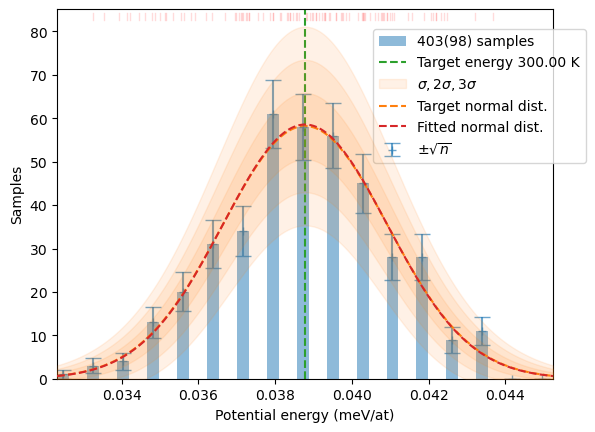

In [5]:
#| asap
plot_stats(distrib, T, sqrN=True)

## Installation

The HECSS package is available on PyPI and conda-forge. Installation is straightforward and handles all dependencies automatically through package managers.

### Install with pip

It is advisable to install in a dedicated virtual environment:

```bash
python3 -m venv venv
source venv/bin/activate  # On Windows: venv\Scripts\activate
pip install hecss
```

### Install with conda

Installation with conda should be performed in a dedicated or existing non-base environment:

```bash
# Create a new environment with hecss
conda create -n hecss -c conda-forge hecss
conda activate hecss

# Or install in an existing environment
conda install -c conda-forge hecss
```

### Example data

Example data and notebooks can be downloaded directly from the [source repository](https://github.com/jochym/hecss/tree/master/examples) or accessed through the Binder link above.

## Development

1.  **Clone the repository:**

    ```bash
    git clone https://gitlab.com/jochym/hecss.git
    cd hecss
    ```

2.  **Create the environment:**
    The repository includes an `environment.yml` file for creating a Conda environment with all dependencies and the package installed in editable mode.

    ```bash
    conda env create -f environment.yml
    conda activate hecss-dev
    ```

3.  **Workflow:**
    This project uses `nbdev`. All code changes should be made in the notebooks located in the `nbs/` directory.

    *   After modifying notebooks, run:
        
        ```bash
        nbdev_export
        ```
    *   To update the README, modify `nbs/index.ipynb` and run:
        
        ```bash
        nbdev_readme
        ```
    *   To generate full documentation locally, run:
        
        ```bash
        nbdev_docs
        ```